# 个性化联邦学习算法对比分析 (Personalized FL Analysis)

本 Notebook 用于对比分析个性化联邦学习算法（如 FedRep, FedPer, FedALA 等）在相同实验配置下的性能表现。

In [4]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from plot.utils import load_plot, load_plot_all_runs, ResultLoader

In [ ]:
# --- 实验组定义 ---
experiments = {
    # 基准算法
    "Local": ("local", {}),

    # 层拆分类 (Layer-based)
    "FedPer": ("fedper", {}),
    "FedRep": ("fedrep", {"epochs_head": 5}),

    # 原型与知识蒸馏 (Proto & Distillation)
    "FedProto": ("fedproto", {"mu": 1.0}),
    "FedKD": ("fedkd", {"lr_g": 0.01, "energy": 0.9}),
    "FML": ("fml", {"alpha_fml": 1.0, "beta_fml": 1.0}),

    # 聚合优化类 (Aggregation-based)
    "FedALA": ("fedala", {"eta": 1.0, "rand_percent": 20, "layer_idx": 1}),
    "FedSA": ("fedsa", {"alpha_sa": 0.9999, "lambda_r": 0.1})
}

# --- 通用参数 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "rounds": 200,
    "lr": 0.01,
    "batch_size": 64
}

loader = ResultLoader(base_dir="../results_ray")

Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
Local                |         83.2329 |         82.7436
FedAvg               |         65.5833 |         65.3617
FedPer               |         86.1364 |         86.0291
FedRep               |         85.9242 |         85.3141
FedProto-Model       |         84.4270 |         84.1276
FedProto-Proto       |         84.3055 |         84.1684
FedKD                |         85.5802 |         84.1082
FML-Model            |         84.9602 |         84.6344
FML-Global           |         66.5167 |         66.1783
FedALA               |         87.6408 |         87.3085
ProxyFL-Model        |         76.7915 |         14.7605
FedSA                |         84.2267 |         84.1157
-----------------------------------------------

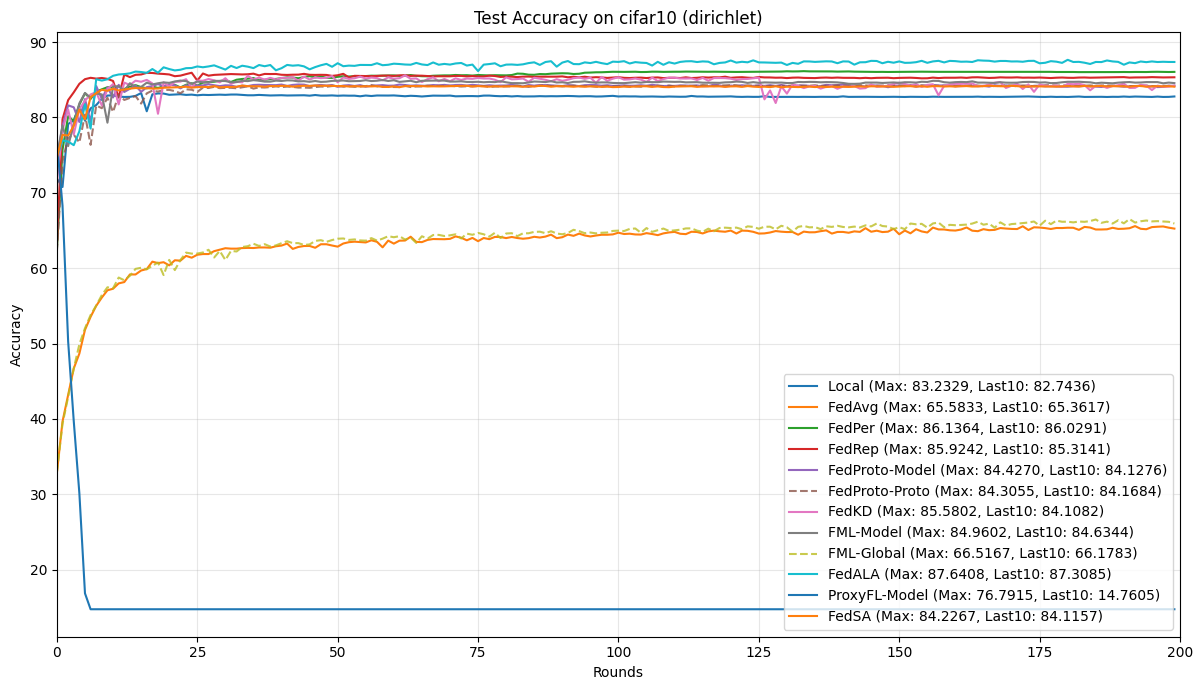

In [8]:
# 1. 加载并绘制曲线 (Run 0)
load_plot(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)

In [7]:
# 2. 统计所有 Run 的平均性能
load_plot_all_runs(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
Local                     |  83.3040 ± 0.0882  |  82.8427 ± 0.1157  (5 runs)
FedAvg                    |  65.2417 ± 0.3524  |  64.8952 ± 0.4071  (5 runs)
FedPer                    |  85.9196 ± 0.2736  |  85.8243 ± 0.3417  (5 runs)
FedRep                    |  85.6298 ± 0.2802  |  85.1004 ± 0.1800  (5 runs)
FedProto-Model            |  84.0174 ± 0.3392  |  83.6995 ± 0.3085  (5 runs)
FedProto-Proto            |  83.7848 ± 0.3548  |  83.5595 ± 0.3953  (5 runs)
FedKD                     |  85.1933 ± 0.4009  |  84.4037 ± 0.6330  (5 runs)
FML-Model                 |  84.9551 ± 0.0542  |  84.6527 ± 0.0362  (5 runs)
FML-Global                |  66.5683 ± 0.1202  |  66.3117 ± 0.1410  (5 runs)
FedALA                    |  87.3817 ± 0.2472  |